In [61]:
from urllib.request import urlopen
import json
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
import matplotlib.pyplot as plt
import time
import plotly.express as px
import matplotlib.dates as mdates
from pandas.tseries.offsets import MonthEnd

In [62]:
def get_data(api_url):
    response = urlopen(api_url)

    if response.getcode() == 200:
        data = response.read().decode('utf-8')  # Read and decode the response
        json_data = json.loads(data)  # Parse the JSON string
#         print(json_data)
        return json_data
    else:
        print(f"Error: Unable to fetch data. Status code: {response.getcode()}")
        return None

In [63]:
def create_api(index, period, terms, term_id, dic):
    #index - индекс показателя
    #period 
        #4- месяц
        #5 -квартал
        #7 - год
    #terms - классификации через запятую, в соответсвии с видами классификаци dic
        # РК - 741880
        # отчетный период к предыдущему периоду - 2695730
        # категория показателя
    #term_id - выбрать одну классификацию из terms
    # вид классификации
        #67 - Регионы
        #848 -соотнесение периодов
        #дополнительная разбивка в зависимости от показателя 
            # 2817 - рынок жилья 
            ####
    
    return f"https://taldau.stat.gov.kz/ru/Api/GetIndexTreeData?p_measure_id=1&p_index_id={index}&p_period_id={period}&p_terms={terms}&p_term_id={term_id}&p_dicIds={dic}&idx=0&p_parent_id="

# Inflation

In [64]:
def get_inflation_data(name, code):
    data = get_data(create_api('703076', '4', f'741880,{code},4772381', '741880', '67,848,2753'))
    # cpi_m = get_data(create_api('703076', '4', '741880,2695730,4772381', '741880', '67,848,2753'))
    #y 2695732
    #m 2695730
    
    df = pd.DataFrame(columns = ['date', 'cpi', 'num'])
    date = []
    cpi = []
    num = []
    for i in [d for d in list(data[0].keys()) if d[:1] == 'y']:
        date.append(i)
        cpi.append(float(data[0][i]))
        num.append(int(data[0][i[1:]]))
    #     print(i,data[0][i], data[0][i[1:]])
    df.date = date
    df.cpi = cpi
    df.num = num
    df = df.set_index('num').sort_index().reset_index()
    df.date = pd.date_range(start = '2011-01-01', freq = 'ME', periods = df.shape[0])
    df.set_index('date', inplace = True)
    df.columns = ['num', name]
    
    return df[[name]]

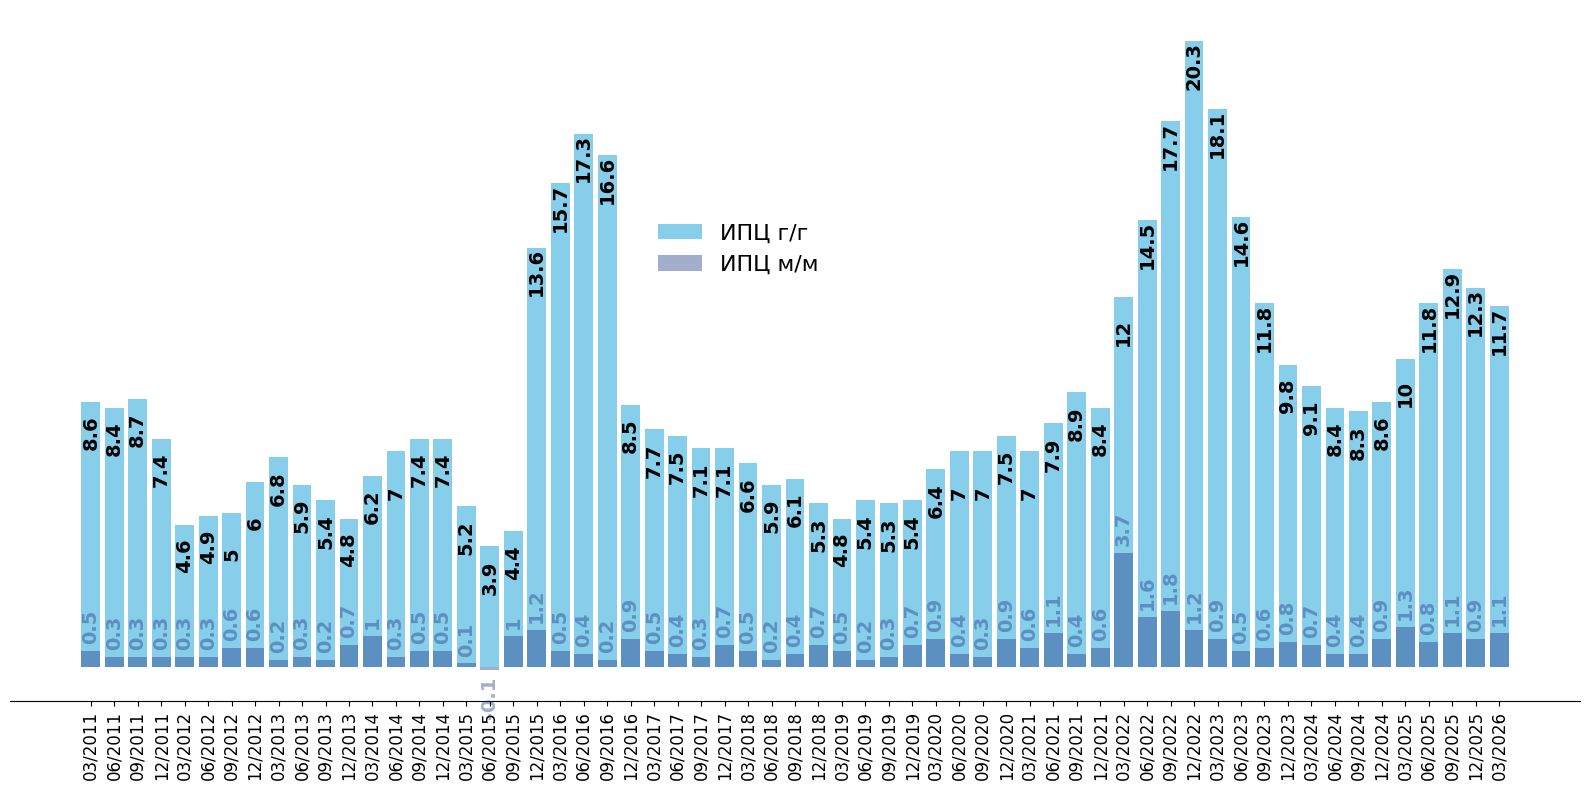

In [65]:
cpi_y = get_inflation_data('cpi_y', '2695732')
time.sleep(2)
cpi_m = get_inflation_data('cpi_m', '2695730')
data = cpi_y.join(cpi_m)
data = data - 100
data = data.resample('QE').last()

plt.rc('axes.spines', **{'bottom':True, 'left':False, 'right':False, 'top':False})
fig, ax = plt.subplots(figsize=(16, 8))

bar1 = ax.bar(data['2011':].index.strftime('%m/%Y'), data['2011':].cpi_y, label='ИПЦ г/г', color = 'skyblue')
bar2 = ax.bar(data['2011':].index.strftime('%m/%Y'), data['2011':].cpi_m, label='ИПЦ м/м', color = (0.1, 0.2, 0.5, 0.4))

ax.bar_label(bar1, label_type='edge',rotation=90, padding = -35, fontweight='bold', fontsize = 14)
ax.bar_label(bar2, label_type='edge', rotation=90, padding = 5, color = (0.1, 0.2, 0.5, 0.4), fontweight='bold', fontsize = 14)

ax.tick_params(axis='x', rotation=90, labelsize=12)
ax.yaxis.set_visible(False)

plt.legend(frameon=False, loc='best', bbox_to_anchor=(0.4, 0., 0.5, 0.72), fontsize = 16)
plt.tight_layout()

In [66]:
data = data.reset_index()
old_data = pd.read_excel('CPI_OLD.xlsx', sheet_name='READY_Q')
old_data
data = pd.concat([data, old_data])
data = data.sort_values(by='date')

In [67]:
data = data.set_index('date')

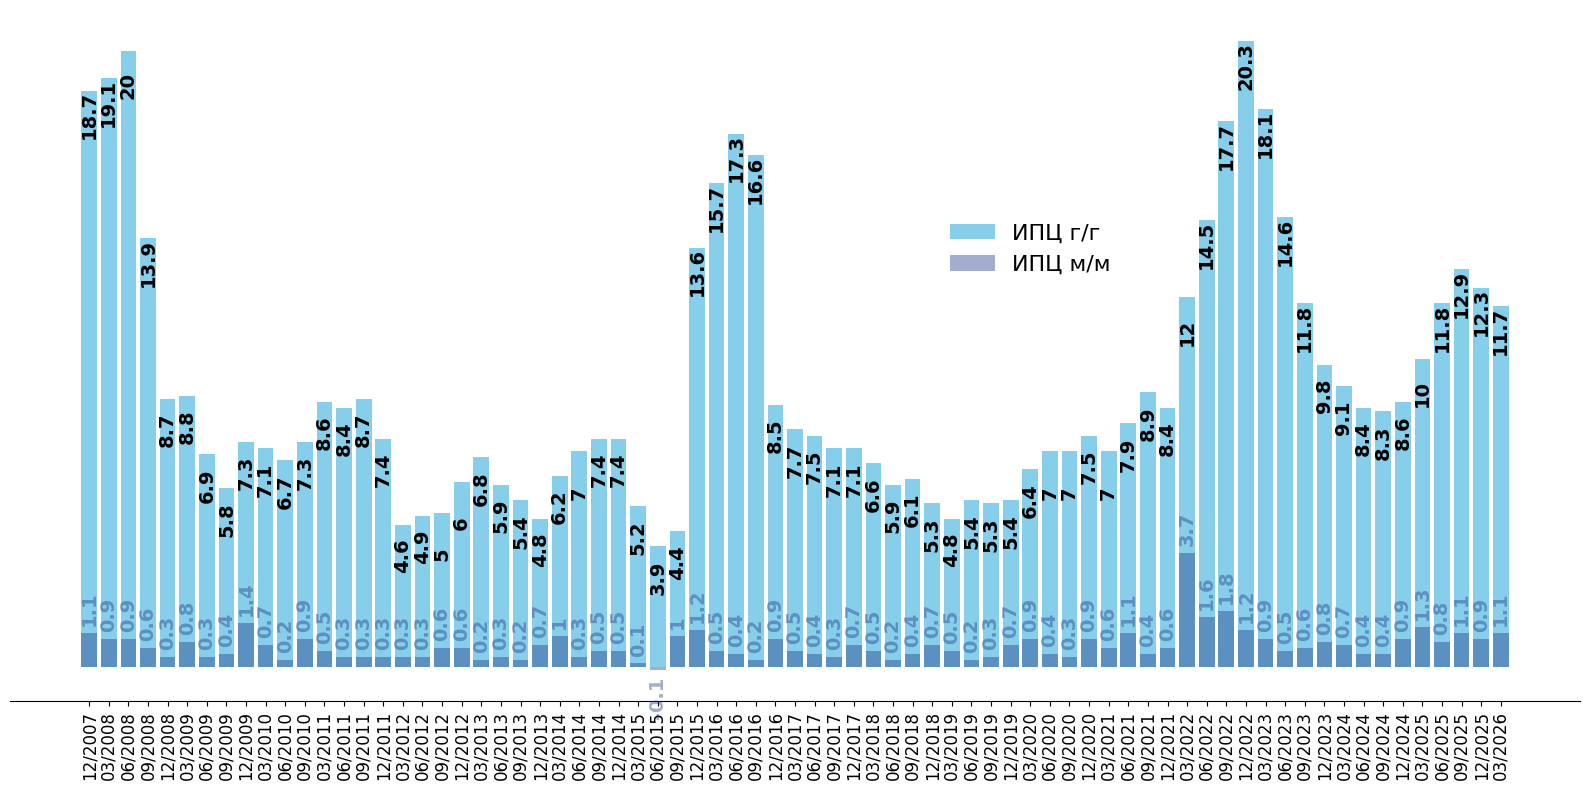

In [68]:
plt.rc('axes.spines', **{'bottom':True, 'left':False, 'right':False, 'top':False})
fig, ax = plt.subplots(figsize=(16, 8))

bar1 = ax.bar(data['2005':].index.strftime('%m/%Y'), data['2005':].cpi_y, label='ИПЦ г/г', color = 'skyblue')
bar2 = ax.bar(data['2005':].index.strftime('%m/%Y'), data['2005':].cpi_m, label='ИПЦ м/м', color = (0.1, 0.2, 0.5, 0.4))

ax.bar_label(bar1, label_type='edge',rotation=90, padding = -35, fontweight='bold', fontsize = 14)
ax.bar_label(bar2, label_type='edge', rotation=90, padding = 5, color = (0.1, 0.2, 0.5, 0.4), fontweight='bold', fontsize = 14)

ax.tick_params(axis='x', rotation=90, labelsize=12)
ax.yaxis.set_visible(False)

plt.legend(frameon=False, loc='best', bbox_to_anchor=(0.4, 0., 0.5, 0.72), fontsize = 16)
plt.tight_layout()

# USDKZT

In [69]:
def usdkzt(start, end):
    # url = f"https://www.nationalbank.kz/ru/exchangerates/ezhednevnye-oficialnye-rynochnye-kursy-valyut/excel?_token=9ERza0cHyAtbL8aH6vENg1RVo0zVXCWXlUnclYP3&beginDate={start}&endDate={end}&search-exchanges=&rates%5B%5D=5"
    url = f"https://www.nationalbank.kz/ru/exchangerates/ezhednevnye-oficialnye-rynochnye-kursy-valyut/excel?_token=Ro1zuJgPEwB9ABcciAIxjp0qTb94PTedi5hNeKEP&beginDate={start}&endDate={end}&search-exchanges=&rates%5B%5D=5&rates%5B%5D=16"
    df = pd.read_excel(url).set_index('Date')
    df.index = pd.to_datetime(df.index, dayfirst=True)
    return df

def graph_usd(start, end):
    df = usdkzt(start,end)[['USD']]
    year_3 = end[-4:]
    year_2 = str(int(end[-4:])-1)
    year_1 = str(int(end[-4:])-2)
    
    y_1 = df[year_1:year_1]
    y_1.index = y_1.index.strftime("%m/%d")
    y_1.columns = [year_1]
    y_2 = df[year_2:year_2]
    y_2.index = y_2.index.strftime("%m/%d")
    y_2.columns = [year_2]
    y_3 = df[year_3:year_3]
    y_3.index = y_3.index.strftime("%m/%d")
    y_3.columns = [year_3]
    
    y_1 = y_1.join(y_2).join(y_3)

    plt.rc('axes.spines', **{'bottom':True, 'left':False, 'right':False, 'top':False})
    plt.figure(figsize=(8, 8))
    plt.plot(y_1.index, y_1[year_1], label = year_1, linewidth = 3, color = '#808180')
    plt.plot(y_1.index, y_1[year_2], label = year_2, linewidth = 3, color = '#2E5B88')
    plt.plot(y_1.index, y_1[year_3], label = year_3, linewidth = 3, color = '#BB0021')
    
    myFmt = mdates.DateFormatter('%d/%m')
    
    plt.xlim(y_1.index[0], y_1.index[-1])

    plt.gca().xaxis.set_major_formatter(myFmt)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1, bymonthday=-1))

    
    plt.xticks(fontsize=14)
    plt.grid(True, linestyle = '--')
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    # y_1.to_excel('excel/usdkzt.xlsx')
    # plt.tight_layout()
    # plt.savefig('графики/usdkzt_graph1.png', dpi =200)

In [70]:
df = usdkzt('01.01.2006','31.12.2025')[['USD']]

(np.float64(13149.0), np.float64(20453.0))

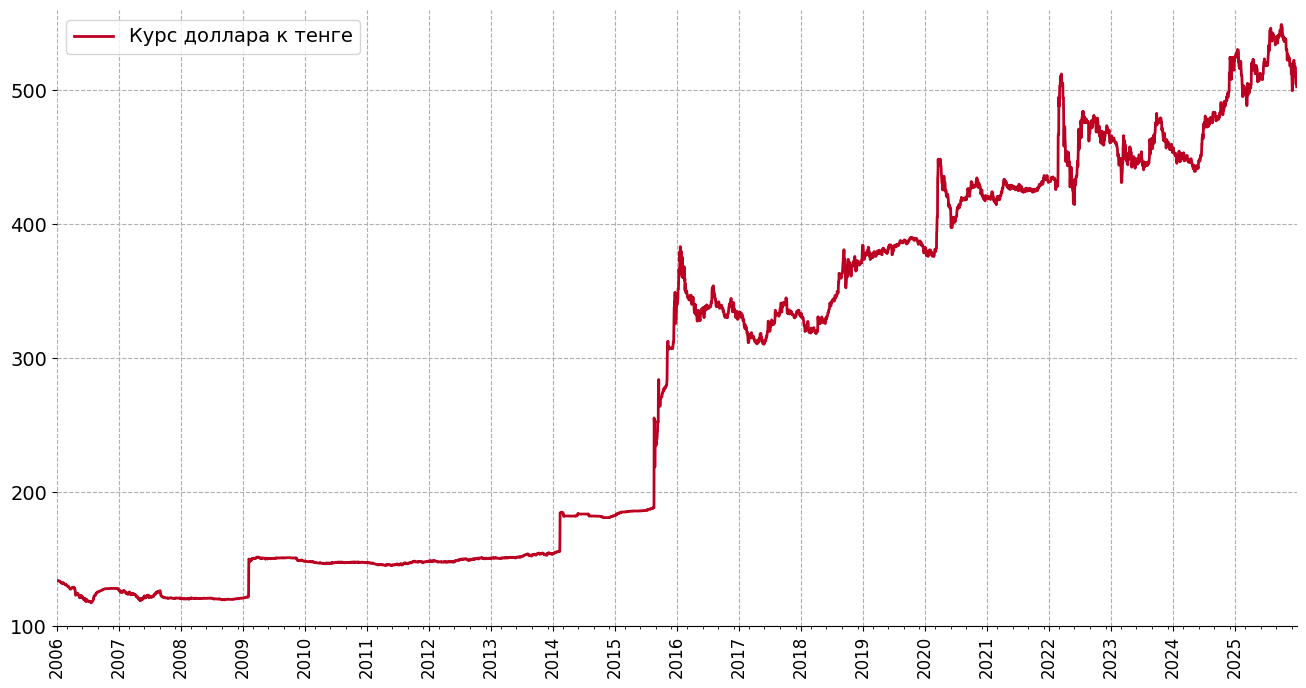

In [71]:
plt.rc('axes.spines', **{'bottom':True, 'left':False, 'right':False, 'top':False})
fig, ax = plt.subplots(figsize=(16, 8))
begin = '2006'
df_usd_kzt = df.resample('QE').last()

ax.plot(df[begin:].index, df[begin:].USD, label = 'Курс доллара к тенге', linewidth = 2, color = '#BB0021')

ax.set_ylim(100, 560)
ax.set_xlim(df[begin:].index[0], df[begin:].index[-1])

ax.xaxis.set_major_locator(mdates.YearLocator())              # раз в год
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3,6,9,12]))

ax.tick_params(axis='x', rotation=90, labelsize=12)
ax.tick_params(axis='y', labelsize=14)

lines, labels = ax.get_legend_handles_labels()
plt.legend(lines, labels[:3], loc=2, ncol=1,fontsize=14)
ax.grid(True, linestyle = '--', axis = 'both')
ax.set_xlim(df[begin:].index[0])

# plt.tight_layout()
# plt.savefig('графики/usdrub.png', dpi =200)

# Real income

In [72]:
def prep_data_income(data, name):
    df = pd.DataFrame(columns = ['date', name, 'num'])
    date = []
    hpi = []
    num = []
    for i in [d for d in list(data[0].keys()) if d[:1] == 'y']:
        date.append(i)
        hpi.append(float(data[0][i]))
        num.append(int(data[0][i[1:]]))
    df.date = date
    df[name] = hpi
    df.num = num
    df = df.set_index('num').sort_index().reset_index()
    year = df.date.str[3:]
    month = df.date.str[1:3]
    df.date = pd.to_datetime(year+'-'+month+'-'+'01') + MonthEnd(0)
    df = df.set_index('date').sort_index()
    return df

In [73]:
real_income = prep_data_income(get_data(create_api('704449', '8', '741880', '741880', '67')), 'total').resample('QE').last()[['total']]
real_income.columns = ['income']
real_income.income = real_income.income-100

In [74]:
real_income = real_income.reset_index()
real_income.head()

,date,income
0,2018-03-31,2.4
1,2018-06-30,3.3
2,2018-09-30,4.6
3,2018-12-31,5.0
4,2019-03-31,7.0


In [75]:
old_income = pd.read_excel('REAL_INCOME_OLD.xlsx', sheet_name='READY_Q')

In [76]:
real_income = pd.concat([real_income, old_income])
real_income = real_income.sort_values(by='date')
real_income = real_income.set_index('date')

In [77]:
real_income

,income
date,
2006-12-31,16.6
2007-03-31,20.0
2007-06-30,21.8
2007-09-30,9.5
2007-12-31,0.4
...,...
2024-12-31,4.6
2025-03-31,0.7
2025-06-30,-0.1


(np.float64(13514.0), np.float64(20453.0))

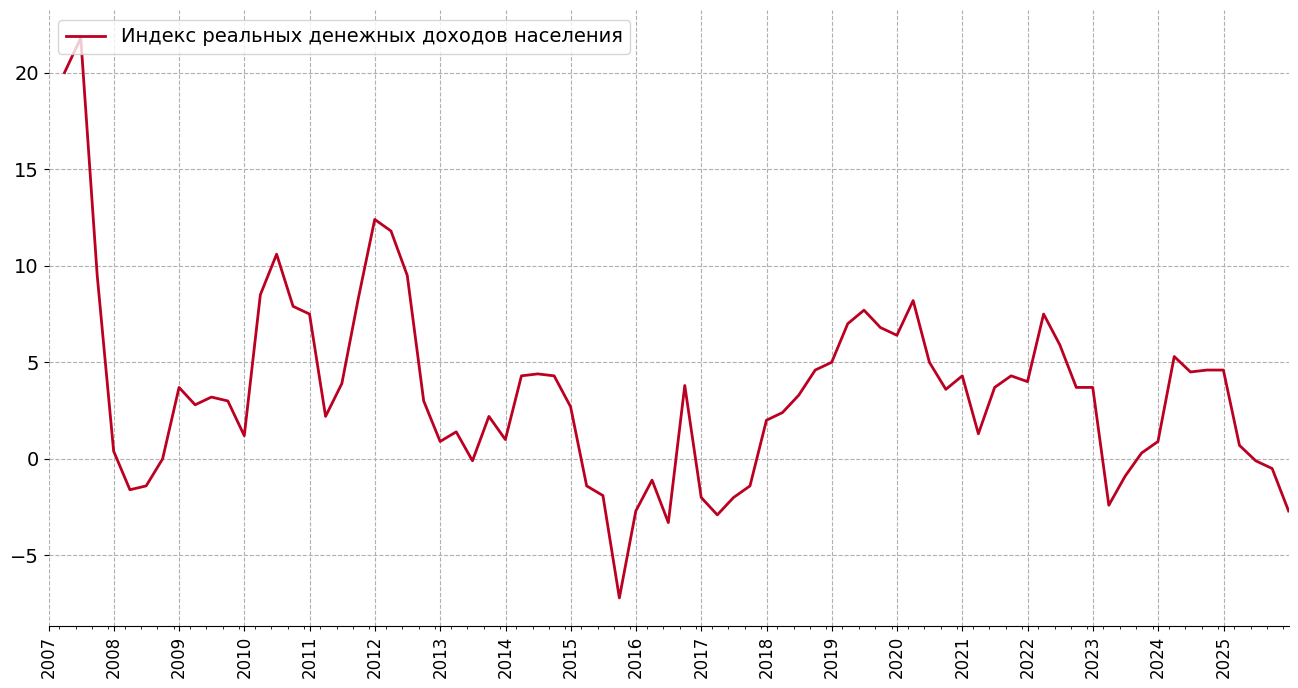

In [78]:
plt.rc('axes.spines', **{'bottom':True, 'left':False, 'right':False, 'top':False})
fig, ax = plt.subplots(figsize=(16, 8))
begin = '2007'

ax.plot(real_income[begin:].index, real_income[begin:].income, label = 'Индекс реальных денежных доходов населения', linewidth = 2, color = '#BB0021')

ax.set_xlim(real_income[begin:].index[0], real_income[begin:].index[-1])

ax.xaxis.set_major_locator(mdates.YearLocator())              # раз в год
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3,6,9,12]))

ax.tick_params(axis='x', rotation=90, labelsize=12)
ax.tick_params(axis='y', labelsize=14)

lines, labels = ax.get_legend_handles_labels()
plt.legend(lines, labels[:3], loc=2, ncol=1,fontsize=14)
ax.grid(True, linestyle = '--', axis = 'both')
ax.set_xlim(df[begin:].index[0])

# plt.tight_layout()
# plt.savefig('графики/usdrub.png', dpi =200)

# Real GDP

In [79]:
real_gdp = pd.read_excel('https://stat.gov.kz/api/iblock/element/283161/file/ru/', header=None, sheet_name='2')

In [80]:
mask = real_gdp.apply(lambda row: row.astype(str).str.contains(
    "Валовой внутренний продукт методом производства", case=False, na=False).any(), axis=1)

gdp_row = real_gdp[mask]

values = gdp_row.iloc[0, 2:]  # пропускаем текстовые колонки
values = pd.to_numeric(values, errors="coerce")

values = values.dropna().reset_index(drop=True)

dates = pd.date_range(
    start="2010-03-31", 
    periods=len(values),
    freq="QE")

ts = pd.Series(values.values, index=dates)

rgdp = pd.DataFrame(ts).reset_index()
rgdp = rgdp.rename(columns= {'index':'date', 0:'RGDP'})

In [81]:
rgdp["rgdp_4q_sum"] = rgdp["RGDP"].rolling(window=4).sum()
rgdp["rgdp_4q_sum_lag"] = rgdp["rgdp_4q_sum"].shift(4)
rgdp["rgdp_yoy"] = (
    rgdp["rgdp_4q_sum"] / rgdp["rgdp_4q_sum_lag"] - 1)
rgdp = rgdp.set_index('date')
rgdp.loc[pd.Timestamp("2025-12-31"), "rgdp_yoy"] = 0.065

In [82]:
rgdp

,RGDP,rgdp_4q_sum,rgdp_4q_sum_lag,rgdp_yoy
date,,,,
2010-03-31,4.935623e+06,NaN,NaN,NaN
2010-06-30,5.487038e+06,NaN,NaN,NaN
2010-09-30,6.203798e+06,NaN,NaN,NaN
2010-12-31,6.993912e+06,2.362037e+07,NaN,NaN
2011-03-31,5.372733e+06,2.405748e+07,NaN,NaN
...,...,...,...,...
2024-12-31,1.115826e+07,3.914145e+07,3.725290e+07,0.050695
2025-03-31,8.964051e+06,3.957188e+07,3.763061e+07,0.051588
2025-06-30,9.718385e+06,4.025707e+07,3.779286e+07,0.065203


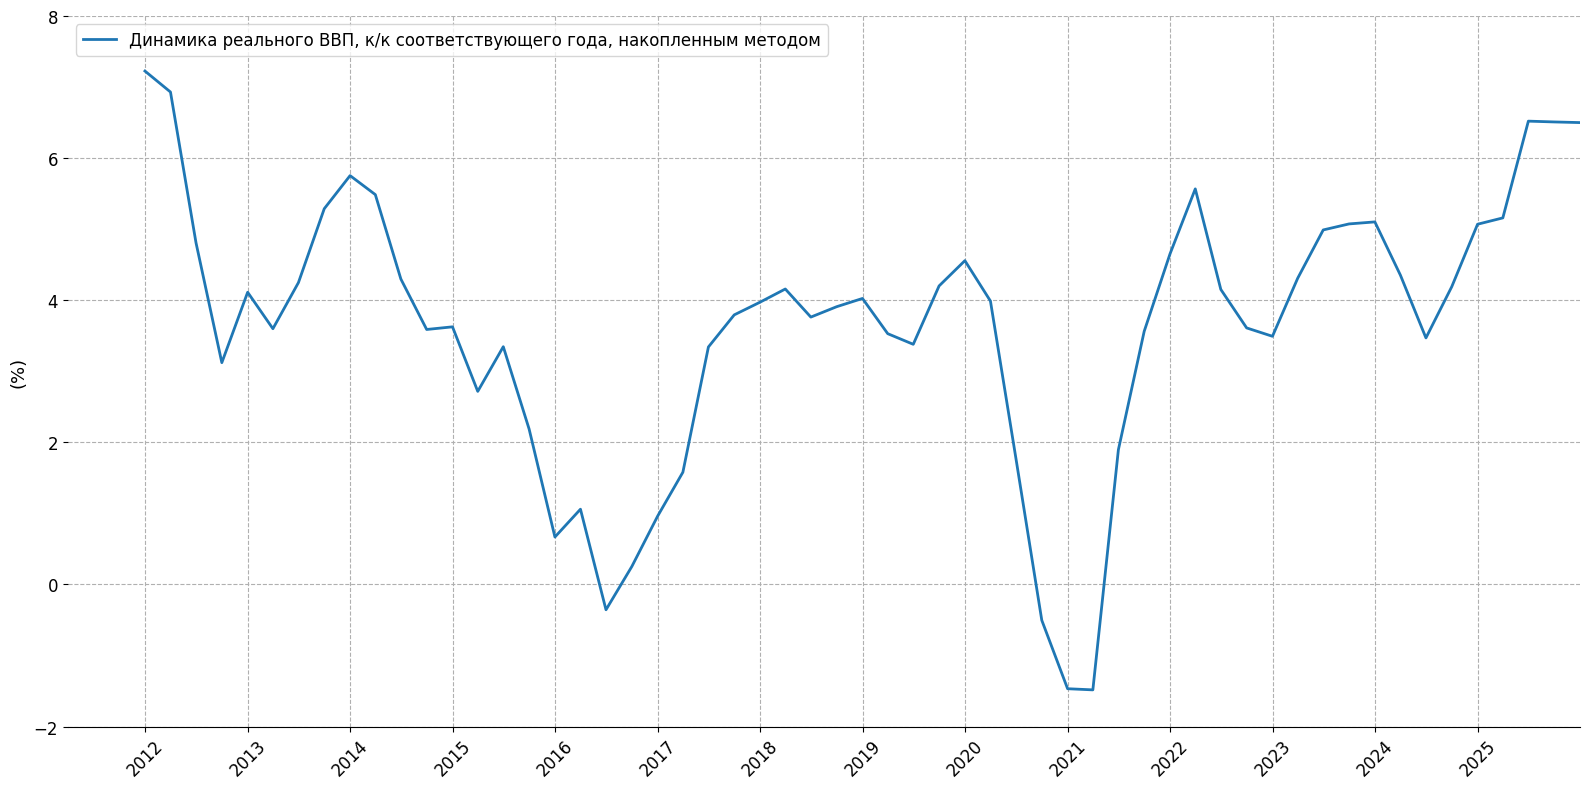

In [83]:
fig, ax = plt.subplots(figsize=(16, 8))

begin = '2011'  

data = rgdp.loc[begin:]

ax.plot(
    data.index,
    data["rgdp_yoy"] * 100, 
    label="Динамика реального ВВП, к/к соответствующего года, накопленным методом",
    linewidth=2)

ax.set_xlim(data.index[0], data.index[-1])
ax.set_ylim(-2, 8)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_ylabel("(%)", fontsize=13)

ax.grid(True, linestyle='--', axis='both')

ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

# Merge

In [84]:
cpi_y = cpi_y.resample('QE').last()
cpi_y.cpi_y = cpi_y.cpi_y -100

In [85]:
macro = pd.concat([rgdp['rgdp_yoy'], df_usd_kzt, cpi_y, real_income], axis = 1)

In [86]:
macro['cpi_y'] = macro['cpi_y']/100
macro['income'] = macro['income']/100

In [87]:
macro["USD_lag_1"] = macro["USD"].shift(1)
macro["USD_KZT_qoq"] = (macro["USD"] / macro["USD_lag_1"] - 1)

In [88]:
macro = macro.drop(columns = ['USD', 'USD_lag_1'])

In [89]:
macro = macro[macro.index <= pd.Timestamp("2025-12-31")]
macro

,rgdp_yoy,cpi_y,income,USD_KZT_qoq
2006-03-31,NaN,NaN,NaN,NaN
2006-06-30,NaN,NaN,NaN,-0.075983
2006-09-30,NaN,NaN,NaN,0.071868
2006-12-31,NaN,NaN,0.166,-0.001729
2007-03-31,NaN,NaN,0.200,-0.024882
...,...,...,...,...
2024-12-31,0.050695,0.086,0.046,0.092461
2025-03-31,0.051588,0.100,0.007,-0.038431
2025-06-30,0.065203,0.118,-0.001,0.033709
2025-09-30,0.065091,0.129,-0.005,0.054574


In [90]:
macro = macro.dropna(axis=0)
macro.reset_index().to_excel('macro_data.xlsx', index=False)